# **Explainable AI with SHAP**


We will cover:

*   **Feature Importance**
*   **SHAP Summary Plot**
*   **SHAP Bar Plot**

In [10]:
# Install SHAP library if not already installed
!pip install shap

# Import necessary libraries
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Mount Google Drive (assuming it's already mounted from previous steps, but good to include for completeness)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading the Trained Model and Test Data



In [11]:
# Define paths to your model and test data (adjust as necessary)
# Assuming 'test_processed.csv' contains X_test and y_test, and 'XGBoost_model.joblib' is the trained model.
TEST_DATA_PATH = '/content/drive/MyDrive/processed_data/test_processed.csv'
MODEL_PATH = '/content/drive/MyDrive/processed_data/xgboost_model.pkl'

# Load the test data
try:
    test_df = pd.read_csv(TEST_DATA_PATH)
    # Assuming 'Churn' is the target variable
    X_test = test_df.drop('Churn', axis=1)
    y_test = test_df['Churn']
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
    display(X_test.head())
except FileNotFoundError:
    print(f"Error: Test data file not found at {TEST_DATA_PATH}. Please check the path.")
    print("You may need to upload or create this file if it does not exist.")
    # Create dummy data for demonstration if file not found
    X_test = pd.DataFrame(np.random.rand(100, 5), columns=[f'feature_{i}' for i in range(5)])
    y_test = pd.Series(np.random.randint(0, 2, 100))
    print("Using dummy data for demonstration due to file not found.")

# Load the trained XGBoost model
try:
    model = joblib.load(MODEL_PATH)
    print("XGBoost model loaded successfully.")
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}. Please check the path.")
    print("You may need to train and save an XGBoost model first.")
    # Create a dummy model for demonstration if file not found
    from xgboost import XGBClassifier
    model = XGBClassifier(random_state=42)
    model.fit(X_test, y_test)
    print("Using a dummy XGBoost model for demonstration due to file not found.")

X_test shape: (1126, 18)
y_test shape: (1126,)


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,0.822895,-1.307578,1.453559,-0.801823,0.316616,0.822705,1.508178,0.294877,-0.248349,-1.493573,-0.255840,-0.466857,-0.623912,1.480267,2.308351,1.802772,0.997108,0.088910
1,1.900976,0.100006,1.453559,-0.318966,1.036474,-1.215503,0.091233,0.294877,-1.661573,-1.493573,-0.255840,1.482635,1.602791,0.644928,-0.926500,-0.683571,-0.409663,0.650925
2,-0.614545,0.100006,-0.724000,-0.077537,0.316616,-1.215503,1.508178,0.294877,-0.248349,-1.493573,1.258356,-0.466857,-0.623912,2.315607,0.151783,-0.328379,1.278462,-0.165922
3,1.781189,1.507590,-0.724000,-0.922538,0.316616,-1.215503,-1.325711,0.294877,0.458262,-0.771089,1.258356,1.482635,-0.623912,-0.190412,-0.926500,-0.328379,-0.691017,-0.922066
4,-0.734332,-1.307578,1.453559,-0.922538,0.316616,-1.215503,-1.325711,-0.675976,-1.661573,-0.048604,-0.255840,-0.856755,1.602791,0.923374,3.386635,2.157964,0.434400,0.430519


XGBoost model loaded successfully.


### Calculating SHAP Values



In [12]:
# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

SHAP values calculated.


### SHAP Summary Plot: Feature Importance and Impact

The SHAP summary plot combines feature importance with feature effects. Each dot represents an observation (a row in `X_test`).

*   **Position on the x-axis:** Represents the SHAP value for that feature, indicating its impact on the model's output (e.g., higher values push prediction towards positive class, lower values towards negative class).
*   **Color:** Represents the feature's actual value (red for high, blue for low).
*   **Vertical Dispersion:** Shows how many different SHAP values a feature has, often indicating its overall importance.

This plot helps us understand which features are most important and whether high/low values of those features increase or decrease the prediction.

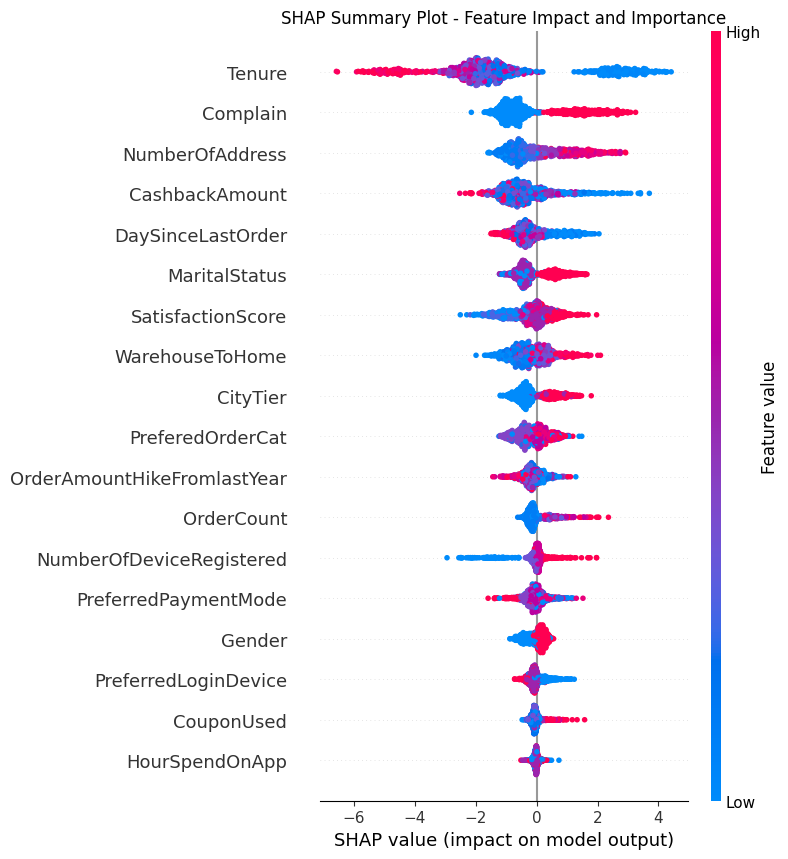

In [13]:
# Generate the SHAP summary plot
# The first argument 'shap_values' can be a list if it's a multi-output model,
# but for binary classification, it's typically a single array. If shap_values is a list of arrays for different classes,
# we usually plot for the positive class (index 1).

# Check if shap_values is a list (for multi-class output) or a single array
if isinstance(shap_values, list):
    # For binary classification, we often focus on the positive class (index 1)
    shap.summary_plot(shap_values[1], X_test, show=False)
else:
    shap.summary_plot(shap_values, X_test, show=False)

plt.title('SHAP Summary Plot - Feature Impact and Importance')
plt.tight_layout()
plt.show()

### SHAP Bar Plot: Global Feature Importance

The SHAP bar plot provides a global view of feature importance. It averages the absolute SHAP values for each feature across all instances, showing which features have the largest overall impact on the model's predictions. This is a common way to visualize overall feature importance, similar to permutation importance or Gini importance, but rooted in SHAP values.

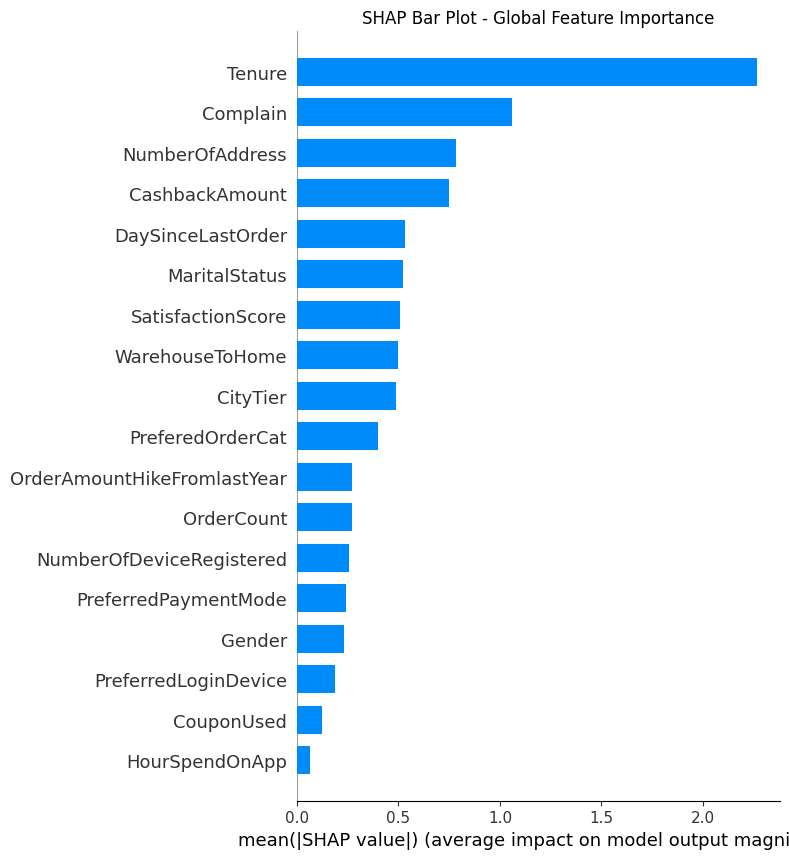

In [14]:
# Generate the SHAP bar plot (global feature importance)
# Again, handle potential list output for multi-class
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.title('SHAP Bar Plot - Global Feature Importance')
plt.tight_layout()
plt.show()